In [101]:
import _config
import importlib
importlib.reload(_config)
import geopandas as gpd
import requests
from shapely.geometry import shape
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import LineString, MultiLineString

In [102]:
# import segments
gdfWfSegments = gpd.read_file(_config.fnWfSegments)
display(gdfWfSegments)

,SEGID,BMP,EMP,DISTANCE,geometry
0,0006_141.0,141.035,146.868,5.843301,"LINESTRING (405824.110 4423860.330, 406035.300..."
1,0006_146.9,146.868,149.902,3.039023,"LINESTRING (413442.550 4422753.728, 413459.600..."
2,0006_149.9,149.902,150.580,0.677983,"LINESTRING (418330.800 4422866.000, 418629.100..."
3,0006_150.6,150.580,152.555,1.973104,"LINESTRING (419421.880 4422872.296, 419780.300..."
4,0006_152.6,152.555,152.871,0.316275,"LINESTRING (422596.900 4422889.295, 422598.500..."
...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,"LINESTRING (420577.907 4495035.704, 420598.660..."
5476,WFRC_8490,0.000,0.000,0.737896,"LINESTRING (421385.500 4495026.200, 421744.807..."
5477,WFRC_8491,0.000,0.000,0.265495,"LINESTRING (422563.717 4495144.584, 422817.227..."
5478,WFRC_8492,0.000,0.000,0.444725,"LINESTRING (423341.022 4513066.226, 423346.007..."


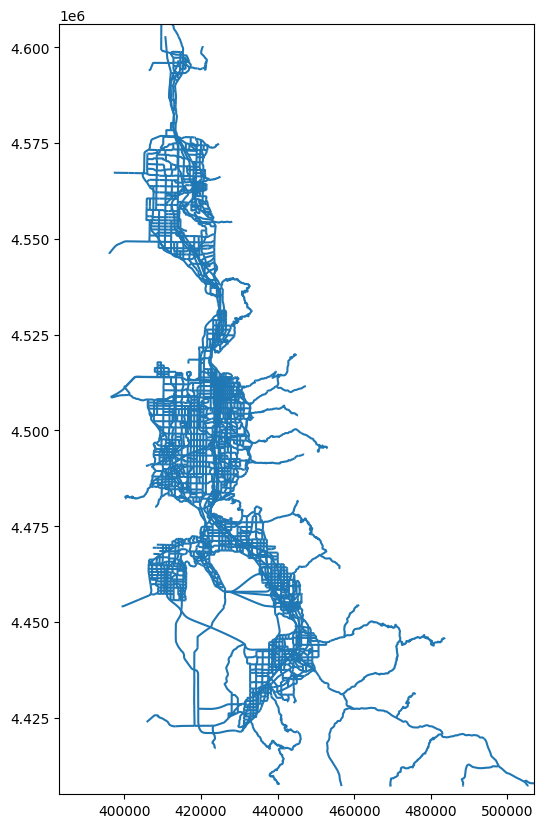

In [103]:
gdfWfSegments = gdfWfSegments.set_crs(epsg=_config.utmzone12n, allow_override=True)

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdfWfSegments.plot(ax=ax)

# Normally, you would set the limits based on the UTM coordinates of your area of interest
ax.set_xlim([_config.utm_x_min, _config.utm_x_max])
ax.set_ylim([_config.utm_y_min, _config.utm_y_max])

plt.show()

In [104]:
# The URL of the feature service
url = _config.countiesService

import requests

# Parameters for fetching the data
params = {
    'where': '1=1',  # This condition effectively means "fetch all"
    'outFields': '*',  # Fetch all fields
    'outSR': '4326',  # Specify the spatial reference (WGS84)
    'f': 'geojson',  # Get the output in GeoJSON format
}

# Make the request
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    # Convert the response to GeoJSON
    data = response.json()
    
    # Extract the features
    features = data['features']
else:
    print("Failed to fetch data:", response.status_code)


# Convert the collected features to a GeoDataFrame
gdfCounties = gpd.GeoDataFrame.from_features(features)

# Set and reproject the CRS to UTM Zone 12N
gdfCounties = gdfCounties.set_crs('EPSG:4326', allow_override=True)
gdfCounties = gdfCounties.to_crs(epsg=_config.utmzone12n)

# Display the GeoDataFrame
display(gdfCounties.head(5))

,geometry,OBJECTID,COUNTYNBR,ENTITYNBR,ENTITYYR,NAME,FIPS,STATEPLANE,POP_LASTCENSUS,POP_CURRESTIMATE,GlobalID,FIPS_STR,COLOR4,Shape__Area,Shape__Length
0,"POLYGON ((404244.485 4650170.221, 404424.575 4...",1,03,2010031010,2010,CACHE,5,North,133154,140173,ad3015be-b3c9-4316-b8dc-03afbb56b443,49005,2,5.456780e+09,388684.773484
1,"POLYGON ((563089.539 4520415.681, 563176.039 4...",2,07,2010071010,2010,DUCHESNE,13,Central,19596,20161,7f6252b7-137f-4f7e-a19a-03c702111509,49013,4,1.448945e+10,517976.270842
2,"POLYGON ((416535.543 4556181.870, 417117.214 4...",3,06,2010061010,2010,DAVIS,11,North,362679,369948,214e29a1-cc25-4867-9148-2817db623088,49011,3,2.890084e+09,279318.042716
3,"POLYGON ((393591.085 4378949.260, 393812.725 4...",4,14,2010141010,2010,MILLARD,27,Central,12975,13330,bc91c742-7508-4118-8469-297719e423cb,49027,3,2.942199e+10,742424.559718
4,"POLYGON ((466563.528 4504441.182, 466573.528 4...",5,26,2010261010,2010,WASATCH,51,Central,34788,36619,3d0c5c1e-2650-458e-b322-2b86aa473441,49051,2,5.396133e+09,436612.959291


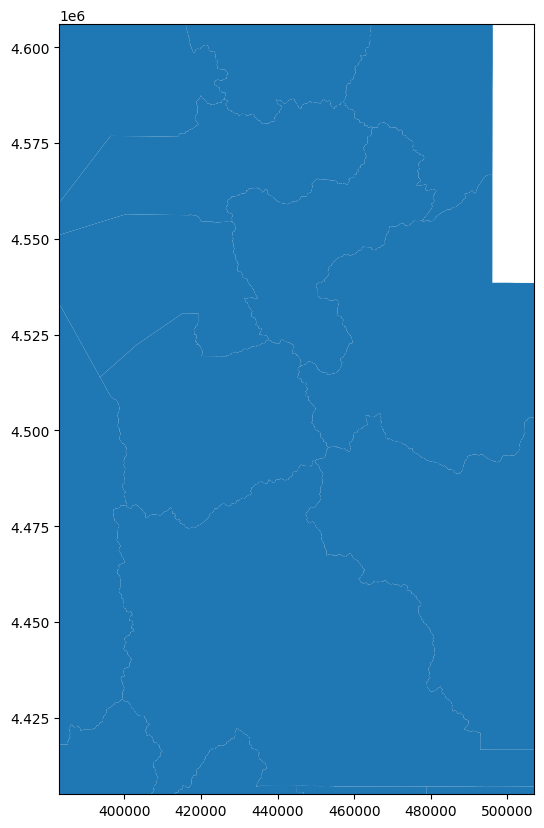

In [105]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdfCounties.plot(ax=ax)

# Normally, you would set the limits based on the UTM coordinates of your area of interest
ax.set_xlim([_config.utm_x_min, _config.utm_x_max])
ax.set_ylim([_config.utm_y_min, _config.utm_y_max])

plt.show()

In [106]:
# Assuming gdfWfSegments is your GeoDataFrame with polylines
gdfWfSegments['centroid_on_line'] = gdfWfSegments.geometry.apply(lambda x: x.interpolate(0.5, normalized=True))

# Create a GeoDataFrame from the centroids
gdfCentroids = gpd.GeoDataFrame(gdfWfSegments, geometry=gdfWfSegments['centroid_on_line'])

# Ensure both GeoDataFrames are in the same CRS
gdfCentroids = gdfCentroids.set_crs(gdfWfSegments.crs, allow_override=True)

# Perform the spatial join with gdfAadt to find the nearest feature # max distance 3 meters
gdfJoined = gpd.sjoin(gdfCentroids, gdfCounties, how="inner", predicate='within')


In [107]:
# Assuming 'segs' is the path to your shapefile and 'gdfJoined' is already defined
gdfWfSegments = gpd.read_file(_config.fnWfSegments)

# Perform the join
# It's more conventional to call merge directly on the DataFrame or GeoDataFrame object
gdfSegmentsWithGeoKeys = gdfWfSegments.merge(gdfJoined[['SEGID','FIPS']], on='SEGID', how='left')

gdfSegmentsWithGeoKeys.rename(columns={'FIPS':'CO_FIPS'}, inplace=True)

gdfSegmentsWithGeoKeys['ROUTE'] = gdfSegmentsWithGeoKeys['SEGID'].str.split('_', expand=True)[0]
gdfSegmentsWithGeoKeys['SUBAREAID'] = gdfSegmentsWithGeoKeys.apply(lambda row: _config.geoKeysByCounty.get(row['CO_FIPS'], {}).get('SUBAREAID'), axis=1)
gdfSegmentsWithGeoKeys['PLANAREA' ] = gdfSegmentsWithGeoKeys.apply(lambda row: _config.geoKeysByCounty.get(row['CO_FIPS'], {}).get('PLANAREA' ), axis=1)

# Set the geometry column
# Assuming 'geometry' is the name of the column in 'gdfSegmentsWithAADT' you want to use as geometry
# This step also ensures 'gdfSegmentsWithAADT' is treated as a GeoDataFrame
gdfSegmentsWithGeoKeys = gpd.GeoDataFrame(gdfSegmentsWithGeoKeys, geometry='geometry')

gdfSegmentsWithGeoKeys = gdfSegmentsWithGeoKeys.set_crs(epsg=_config.utmzone12n, allow_override=True)


gdfSegmentsWithGeoKeys

,SEGID,BMP,EMP,DISTANCE,geometry,CO_FIPS,ROUTE,SUBAREAID,PLANAREA
0,0006_141.0,141.035,146.868,5.843301,"LINESTRING (405824.110 4423860.330, 406035.300...",49,0006,1,MAG
1,0006_146.9,146.868,149.902,3.039023,"LINESTRING (413442.550 4422753.728, 413459.600...",49,0006,1,MAG
2,0006_149.9,149.902,150.580,0.677983,"LINESTRING (418330.800 4422866.000, 418629.100...",49,0006,1,MAG
3,0006_150.6,150.580,152.555,1.973104,"LINESTRING (419421.880 4422872.296, 419780.300...",49,0006,1,MAG
4,0006_152.6,152.555,152.871,0.316275,"LINESTRING (422596.900 4422889.295, 422598.500...",49,0006,1,MAG
...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,"LINESTRING (420577.907 4495035.704, 420598.660...",35,WFRC,1,WFRC
5476,WFRC_8490,0.000,0.000,0.737896,"LINESTRING (421385.500 4495026.200, 421744.807...",35,WFRC,1,WFRC
5477,WFRC_8491,0.000,0.000,0.265495,"LINESTRING (422563.717 4495144.584, 422817.227...",35,WFRC,1,WFRC
5478,WFRC_8492,0.000,0.000,0.444725,"LINESTRING (423341.022 4513066.226, 423346.007...",35,WFRC,1,WFRC


# CHECK MAG_ and WFRC Planning segments in right county

In [108]:
_df = gdfSegmentsWithGeoKeys.copy()

# limit to non numeric
_filtered_df = _df[~_df['ROUTE'].str.isnumeric()]

_filtered_df[_filtered_df['PLANAREA']!=_filtered_df['ROUTE']]


_filtered_df.groupby(['PLANAREA','ROUTE'], as_index=False).agg(COUNT=('SEGID','count'))

,PLANAREA,ROUTE,COUNT
0,MAG,MAG,804
1,MAG,UTA,36
2,WFRC,UTA,93
3,WFRC,WFRC,453


In [109]:
# Get a list of all column names except 'geometry'
cols = [col for col in gdfSegmentsWithGeoKeys.columns if col != 'geometry']

# Add 'geometry' back to the end of the list
cols.append('geometry')

# Reorder the DataFrame by selecting the columns in the new order
gdfSegmentsWithGeoKeys = gdfSegmentsWithGeoKeys[cols]

# Now, the 'geometry' column should be the last column in the DataFrame
gdfSegmentsWithGeoKeys

,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,geometry
0,0006_141.0,141.035,146.868,5.843301,49,0006,1,MAG,"LINESTRING (405824.110 4423860.330, 406035.300..."
1,0006_146.9,146.868,149.902,3.039023,49,0006,1,MAG,"LINESTRING (413442.550 4422753.728, 413459.600..."
2,0006_149.9,149.902,150.580,0.677983,49,0006,1,MAG,"LINESTRING (418330.800 4422866.000, 418629.100..."
3,0006_150.6,150.580,152.555,1.973104,49,0006,1,MAG,"LINESTRING (419421.880 4422872.296, 419780.300..."
4,0006_152.6,152.555,152.871,0.316275,49,0006,1,MAG,"LINESTRING (422596.900 4422889.295, 422598.500..."
...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,35,WFRC,1,WFRC,"LINESTRING (420577.907 4495035.704, 420598.660..."
5476,WFRC_8490,0.000,0.000,0.737896,35,WFRC,1,WFRC,"LINESTRING (421385.500 4495026.200, 421744.807..."
5477,WFRC_8491,0.000,0.000,0.265495,35,WFRC,1,WFRC,"LINESTRING (422563.717 4495144.584, 422817.227..."
5478,WFRC_8492,0.000,0.000,0.444725,35,WFRC,1,WFRC,"LINESTRING (423341.022 4513066.226, 423346.007..."


# Add Direction

Let's check to see if the `Direction` field exists on the segment shapefile. If it exists, then we double check that the directions are correct, and if it doesn't exist we create it.

In [110]:
# Function to determine direction based on the endpoints of the line or multiline
def determine_direction(geometry):
    # Check if the geometry is a single LineString
    if isinstance(geometry, LineString):
        start_point = geometry.coords[0]
        end_point = geometry.coords[-1]
    # Check if the geometry is a MultiLineString
    elif isinstance(geometry, MultiLineString):
        first_line = geometry.geoms[0]
        start_point = first_line.coords[0]
        last_line = geometry.geoms[-1]
        end_point = last_line.coords[-1]
    else:
        return None
    
    # Calculate the differences in x (longitude) and y (latitude)
    dx = abs(end_point[0] - start_point[0])
    dy = abs(end_point[1] - start_point[1])
    
    # Determine the direction
    return "EB/WB" if dx > dy else "NB/SB"

In [111]:
def determine_direction_bounding_box(geometry):
    # Get the bounding box of the geometry (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = geometry.bounds
    
    # Calculate width (horizontal distance) and height (vertical distance)
    width = maxx - minx  # Difference in x-coordinates
    height = maxy - miny  # Difference in y-coordinates
    
    # Determine the direction based on bounding box dimensions
    return "EB/WB" if width > height else "NB/SB"

In [112]:
# Check if the "DIRECTION" field exists in the GeoDataFrame
if 'DIRECTION' not in gdfSegmentsWithGeoKeys.columns:
    print("Field 'DIRECTION' not found. Creating the field...")
    # Create the "Direction" field by applying the function
    gdfSegmentsWithGeoKeys['DIRECTION'] = gdfSegmentsWithGeoKeys['geometry'].apply(determine_direction_bounding_box)

    print("DIRECTION field added and shapefile saved.")

else:
    print("Field 'DIRECTION' already exists. Validating values...")
    # Initialize a list to collect invalid rows
    invalid_entries = []
    
    # Loop through each row and check if the calculated direction matches the existing one
    for idx, row in gdfSegmentsWithGeoKeys.iterrows():
        current_direction = row['DIRECTION']
        calculated_direction = determine_direction_bounding_box(row['geometry'])
        
        # Check for mismatch between current and calculated direction
        if current_direction != calculated_direction:
            invalid_entries.append({
                'Index': idx,
                'Current Direction': current_direction,
                'Calculated Direction': calculated_direction
            })
    
    # Report invalid entries if any exist
    if invalid_entries:
        print("Found mismatched direction values:")
        for entry in invalid_entries:
            print(f"Row {entry['Index']}: Current = {entry['Current Direction']}, Calculated = {entry['Calculated Direction']}")
    else:
        print("All 'DIRECTION' values are valid.")


Field 'DIRECTION' not found. Creating the field...
DIRECTION field added and shapefile saved.


d:\GitHub\WF-TDM-v9x\2_ModelScripts\_Python\py-tdm-env\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


# Write Out File

In [113]:
# write out file
import os

# Split the filename and extension based on the last dot
base, extension = _config.fnWfSegments.rsplit('.', 1)

# Add '_GeoKeys' suffix to the filename part
new_filename = os.path.basename(f"{base}_GeoKeys.{extension}")

gdfSegmentsWithGeoKeys.to_file('intermediate/' + new_filename)
print('Exported: intermediate/' + new_filename)
print("Done!")

Exported: intermediate/WFv910_Segments_GeoKeys.shp
Done!
